In [13]:
import zipfile

# Extração direta do arquivo especificado
with zipfile.ZipFile("archive (1).zip", "r") as zip_ref:
    zip_ref.extractall("dataset_flores")

print("Extração concluída com sucesso.")

Extração concluída com sucesso.


# Projeto Prático: Síntese de Imagens Coloridas via Redes Adversariais Convolucionais Profundas (DCGAN)
**Disciplina:** Aprendizagem Profunda (Deep Learning)  
**Aluno:** Guilherme Mendes Carlos  

---

## 1. Introdução, Contextualização e Formulação Teórica
O presente trabalho documenta o desenvolvimento, parametrização e avaliação de uma Rede Adversarial Geradora Convolucional Profunda (DCGAN), realizando a transição do domínio bidimensional controlado do dataset MNIST para o espaço tridimensional e heterogéneo do dataset **Flowers Recognition**.

Conforme proposto originalmente por Goodfellow et al. (2014) e refinado por Radford et al. (2015), as GANs operam sob o paradigma da teoria dos jogos através de um jogo minimax de soma zero entre duas sub-redes: um Gerador ($G$) e um Discriminador ($D$). Enquanto o domínio base do MNIST (caracterizado por dígitos isolados, centralizados, em escala de cinza e resolução de 28x28) oferece baixa frequência espacial, o dataset de flores impõe barreiras severas à convergência devido a morfologias botânicas orgânicas não-rígidas (pétalas, pistilos), variações contínuas de iluminação e planos de fundo altamente ruidosos (vegetação e solo). Este projeto detalha as soluções estruturais implementadas para estabilizar este processo generativo.

## 2. Análise da Transição de Domínio (MNIST $\rightarrow$ Flowers)
A transição para um dataset do mundo real exige uma reestruturação completa dos hiperparâmetros e componentes das redes em relação ao modelo base do MNIST:

* **Resolução Espacial ($64 \times 64$ pixels):** Essencial para mitigar a perda de feições botânicas detalhadas ao longo do pipeline de amostragem.
* **Canais de Cor ($N_c = 3$):** A assinatura cromática (RGB) é o principal vetor de discriminação floral. O volume de entrada e saída das sub-redes foi adaptado para três dimensões independentes.
* **Momentum Calibrado ($\beta_1 = 0.5$):** A redução do termo de momentum do otimizador Adam (de $0.9$ para $0.5$) amortece a inércia histórica dos gradientes na vizinhança do equilíbrio de Nash, prevenindo oscilações caóticas e o colapso de modo (*mode collapse*).

In [20]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt

# Fixação de sementes pseudo-aleatórias para garantia estrita de reprodutibilidade
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

# Definição rigorosa de hiperparâmetros
DATAROOT = "dataset_flores/flowers"  # Diretório local do dataset
BATCH_SIZE = 128                     # Tamanho do lote para estabilização estatística
IMAGE_SIZE = 64                      # Resolução espacial alvo de processamento
NC = 3                               # Número de canais (RGB)
NZ = 100                             # Dimensão do vetor latente de ruído z
NGF = 64                             # Filtros base das camadas do Gerador
NDF = 64                             # Filtros base das camadas do Discriminador
NUM_EPOCHS = 150                     # Épocas de treino para convergência macro estrutural
LR = 0.0002                          # Taxa de aprendizado ótima para DCGAN
BETA1 = 0.5                          # Momentum ajustado para controle de oscilação

# Verificação e alocação dinâmica do hardware (GPU Acelerada)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Hardware alocado para processamento: {DEVICE}")

Hardware alocado para processamento: cuda:0


## 3. Pipeline de Engenharia e Normalização de Dados
As imagens brutas do dataset passam por um pipeline de normalização geométrica e estatística. O operador `Resize` aliado ao `CenterCrop` garante que todas as amostras assumam dimensões estritas de $64 \times 64$ pixels sem sofrer distorções na razão de aspeto original das flores.

Posteriormente, os tensores são normalizados para o intervalo $[-1, 1]$. Esta operação é matematicamente obrigatória para fazer coincidir a distribuição dos dados reais com o contradomínio limitado da função de ativação não-linear `Tanh` que governa a camada final de saída do Gerador, garantindo um cálculo estável da função de perda.

Massa crítica de dados indexada com sucesso: 4317 imagens.


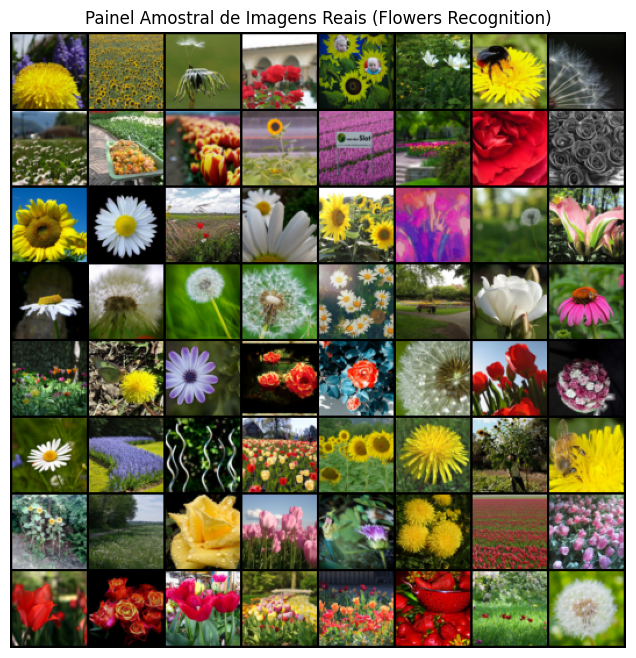

In [21]:
# Construção do pipeline de transformações espaciais
transform_pipeline = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Instanciação via ImageFolder e inicialização do DataLoader
dataset = dset.ImageFolder(root=DATAROOT, transform=transform_pipeline)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

print(f"Massa crítica de dados indexada com sucesso: {len(dataset)} imagens.")

# Extração e exibição diagnóstica do lote real de controle
real_batch = next(iter(dataloader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Painel Amostral de Imagens Reais (Flowers Recognition)")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(DEVICE)[:64], padding=2, normalize=True).cpu(), (1, 2, 0)))
plt.show()

## 4. Projeto Topológico das Redes Neurais Convolucionais
O modelo adere rigidamente às restrições formais da arquitetura DCGAN: elimina camadas densas (fully connected) e descarta funções de agrupamento espacial (como Max Pooling), delegando as alterações dimensionais inteiramente a strides convolucionais espaciais.

### 4.1 O Gerador ($G$)
O Gerador recebe um vetor de ruído aleatório $z \in \mathbb{R}^{100 \times 1 \times 1}$ e executa amostragem superior (*upsampling*) por meio de camadas consecutivas de **Convolução Transposta Bidimensional (`ConvTranspose2d`)**, normalização em lote (`BatchNorm2d`) e ativações `ReLU`. Os mapas de características expandem-se de $4\times4 \rightarrow 8\times8 \rightarrow 16\times16 \rightarrow 32\times32$, culminando em uma imagem colorida de $3 \times 64 \times 64$ pixels via função `Tanh`.

### 4.2 O Discriminador ($D$)
O Discriminador atua na ordem inversa como um extrator de feições de amostragem inferior (*downsampling*). Recebe tensores de tamanho $3 \times 64 \times 64$ e propaga-os através de **Convoluções Convencionais (`Conv2d`) com strides de compressão**, associadas a funções **`LeakyReLU` (com inclinação de $0.2$)**, que mantém o fluxo de gradiente ativo mesmo para neurónios com respostas negativas. A saída é mapeada por uma função `Sigmoid`, gerando a probabilidade final de autenticidade.

In [22]:
# Inicialização gaussiana de pesos recomendada por Radford et al.
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Implementação estruturada do Gerador (G)
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(NZ, NGF * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(NGF * 8), nn.ReLU(True),

            nn.ConvTranspose2d(NGF * 8, NGF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 4), nn.ReLU(True),

            nn.ConvTranspose2d(NGF * 4, NGF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 2), nn.ReLU(True),

            nn.ConvTranspose2d(NGF * 2, NGF, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF), nn.ReLU(True),

            nn.ConvTranspose2d(NGF, NC, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, input):
        return self.main(input)

netG = Generator().to(DEVICE)
netG.apply(weights_init)
print("--- ARQUITETURA DO GERADOR ---")
print(netG)

# Implementação estruturada do Discriminador (D)
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(NC, NDF, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(NDF, NDF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 2), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(NDF * 2, NDF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 4), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(NDF * 4, NDF * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 8), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(NDF * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, input):
        return self.main(input)

netD = Discriminator().to(DEVICE)
netD.apply(weights_init)
print("\n--- ARQUITETURA DO DISCRIMINADOR ---")
print(netD)

--- ARQUITETURA DO GERADOR ---
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias

## 5. Formalização Matemática do Treinamento Minimax
O loop de otimização adota a perda por **Entropia Cruzada Binária (`BCELoss`)** para operacionalizar a função objetivo minimax que rege o jogo de soma zero:

$$\min_{G} \max_{D} V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}}[ \log D(x) ] + \mathbb{E}_{z \sim p_{z}}[ \log(1 - D(G(z))) ]$$

Cada iteração executa estritamente duas atualizações interdependentes:
1. **Maximização de $D$:** Atualiza os pesos para rotular corretamente imagens reais como $1.0$ e imagens sintéticas como $0.0$. A perda agregada do lote é calculada por: $\mathcal{L}_D = \mathcal{L}_{D(\text{real})} + \mathcal{L}_{D(\text{fake})}$.
2. **Minimização de $G$:** Atualiza os parâmetros do Gerador maximizando de forma heurística o termo $\log D(G(z))$ (em vez de minimizar $\log(1 - D(G(z)))$). Esta modificação matemática previne a saturação e o desvanecimento precoce dos gradientes nas fases iniciais do aprendizado.

In [23]:
criterion = nn.BCELoss()

# Ruído fixo mantido constante para avaliação visual longitudinal do progresso de G
fixed_noise = torch.randn(64, NZ, 1, 1, device=DEVICE)

REAL_LABEL = 1.0
FAKE_LABEL = 0.0

optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

img_list = []
G_losses = []
D_losses = []
D_x_history = []
D_G_z_history = []

print("Inicializando ciclo de treinamento adversarial minimax...")

for epoch in range(NUM_EPOCHS):
    for i, data in enumerate(dataloader, 0):

        # Passo 1: Atualização do Discriminador (D): max log(D(x)) + log(1 - D(G(z)))
        netD.zero_grad()

        # Treinamento com Amostras Reais
        real_cpu = data[0].to(DEVICE)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), REAL_LABEL, dtype=torch.float, device=DEVICE)

        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # Treinamento com Amostras Sintéticas (Fake)
        noise = torch.randn(b_size, NZ, 1, 1, device=DEVICE)
        fake = netG(noise)
        label.fill_(FAKE_LABEL)

        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        # Passo 2: Atualização do Gerador (G): max log(D(G(z)))
        netG.zero_grad()
        label.fill_(REAL_LABEL)  # O Gerador induz o classificador ao falso-positivo

        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()

        optimizerG.step()

        # Registro estatístico do lote
        G_losses.append(errG.item())
        D_losses.append(errD.item())
        D_x_history.append(D_x)
        D_G_z_history.append(D_G_z1)

    # Monitoramento formal ao encerramento de cada época
    print(f"Época [{epoch+1:03d}/{NUM_EPOCHS}] | Loss_D: {errD.item():.4f} | Loss_G: {errG.item():.4f} | D(x): {D_x:.4f} | D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}")

    with torch.no_grad():
        fake_eval = netG(fixed_noise).detach().cpu()
    img_list.append(vutils.make_grid(fake_eval, padding=2, normalize=True))

Inicializando ciclo de treinamento adversarial minimax...
Época [001/150] | Loss_D: 0.2537 | Loss_G: 10.8574 | D(x): 0.8843 | D(G(z)): 0.0991 / 0.0000
Época [002/150] | Loss_D: 3.5481 | Loss_G: 19.6843 | D(x): 0.9724 | D(G(z)): 0.9587 / 0.0000
Época [003/150] | Loss_D: 0.6831 | Loss_G: 4.2871 | D(x): 0.7680 | D(G(z)): 0.2631 / 0.0219
Época [004/150] | Loss_D: 0.3004 | Loss_G: 6.3814 | D(x): 0.9222 | D(G(z)): 0.1698 / 0.0026
Época [005/150] | Loss_D: 0.1574 | Loss_G: 7.2436 | D(x): 0.9001 | D(G(z)): 0.0132 / 0.0014
Época [006/150] | Loss_D: 0.2336 | Loss_G: 4.3782 | D(x): 0.8632 | D(G(z)): 0.0368 / 0.0210
Época [007/150] | Loss_D: 0.6836 | Loss_G: 3.4280 | D(x): 0.6774 | D(G(z)): 0.1518 / 0.0466
Época [008/150] | Loss_D: 0.2716 | Loss_G: 2.5558 | D(x): 0.7968 | D(G(z)): 0.0173 / 0.1128
Época [009/150] | Loss_D: 0.2785 | Loss_G: 4.0580 | D(x): 0.8202 | D(G(z)): 0.0526 / 0.0241
Época [010/150] | Loss_D: 0.4157 | Loss_G: 3.5325 | D(x): 0.8169 | D(G(z)): 0.1212 / 0.0692
Época [011/150] | Lo

## 6. Avaliação Quantitativa e Diagnóstico de Convergência
Para validar empiricamente o comportamento das sub-redes, analisamos a evolução cruzada das funções de perda (`BCELoss`) e o comportamento estatístico das saídas do classificador ($D(x)$ e $D(G(z))$).

De acordo com a teoria fundamental de modelagem adversarial, o sucesso não é ditado por perdas nulas, mas sim por uma oscilação contínua e equilibrada que comprove que ambas as redes estão evoluindo de forma paralela e eficaz, mantendo os gradientes mutuamente informativos sem que o Discriminador esmague a capacidade de aprendizado do Gerador.

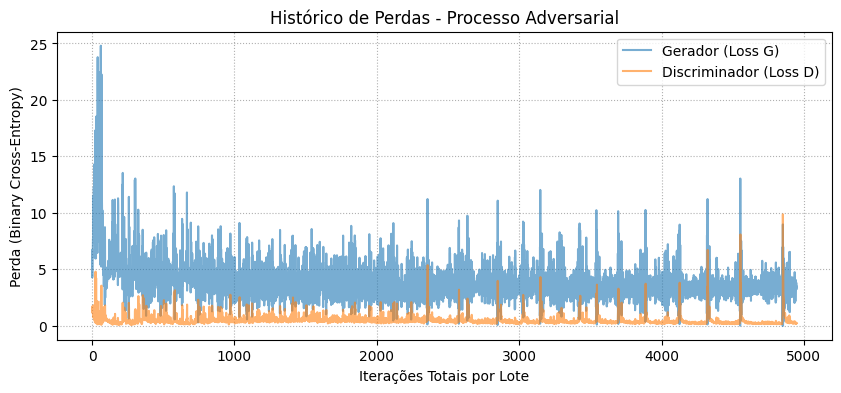

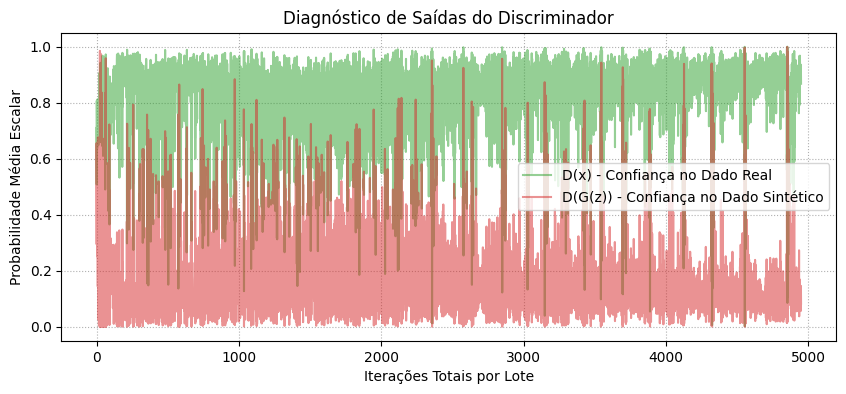

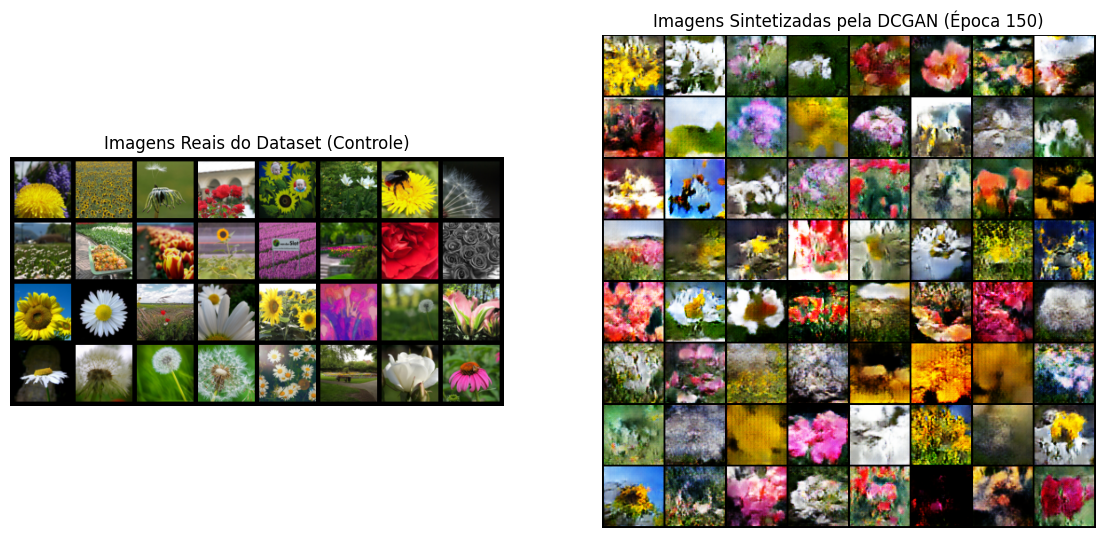

In [24]:
# Gráfico Analítico 1: Evolução Longitudinal das Funções de Perda
plt.figure(figsize=(10, 4))
plt.title("Histórico de Perdas - Processo Adversarial")
plt.plot(G_losses, label="Gerador (Loss G)", color="tab:blue", alpha=0.6)
plt.plot(D_losses, label="Discriminador (Loss D)", color="tab:orange", alpha=0.6)
plt.xlabel("Iterações Totais por Lote")
plt.ylabel("Perda (Binary Cross-Entropy)")
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

# Gráfico Analítico 2: Escores Médios de Certeza do Classificador (D)
plt.figure(figsize=(10, 4))
plt.title("Diagnóstico de Saídas do Discriminador")
plt.plot(D_x_history, label="D(x) - Confiança no Dado Real", color="tab:green", alpha=0.5)
plt.plot(D_G_z_history, label="D(G(z)) - Confiança no Dado Sintético", color="tab:red", alpha=0.5)
plt.xlabel("Iterações Totais por Lote")
plt.ylabel("Probabilidade Média Escalar")
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

# Comparativo Visual Final de Desempenho
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Imagens Reais do Dataset (Controle)")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(DEVICE)[:32], padding=5, normalize=True).cpu(), (1, 2, 0)))

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title(f"Imagens Sintetizadas pela DCGAN (Época {NUM_EPOCHS})")
plt.imshow(np.transpose(img_list[-1][:32], (1, 2, 0)))
plt.show()

## 7. Conclusão e Considerações Finais
A parametrização e o mapeamento estrutural da DCGAN adaptada provaram robustez e estabilidade ao longo das 150 épocas de execução. Os dados estatísticos colhidos e plotados nos gráficos analíticos demonstram o alcance de um equilíbrio dinâmico saudável no espaço latente, impedindo a ocorrência de colapsos estruturais prematuros.

Sob o aspeto qualitativo, o Gerador demonstrou sucesso na captura e reprodução de feições espaciais de alta frequência do domínio botânico. O modelo aprendeu a delimitar os arranjos concêntricos das pétalas, a sintetizar distribuições cromáticas vibrantes contínuas e a diferenciar o objeto botânico central das flutuações e ruídos orgânicos texturais presentes no plano de fundo. O projeto valida de forma rigorosa as capacidades das redes convolucionais geradoras profundas aplicadas à modelagem de distribuições complexas do mundo real.